In [1]:
using Revise
includet("../../scripts/single_influx.jl")
import SSMCMain.ModifiedMiCRM.MinimalModelV2, SSMCMain.ModifiedMiCRM.MinimalModelV3

In [2]:
using ProgressMeter
using ColorSchemes
using UnPack

In [3]:
includet("../../scripts/ternary_colormap.jl")
using .TernaryColormaps

In [4]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Load data

In [5]:
# The main dataset for the phase diagram in fig. 2, K and li sampled at decent density
includet("../../cluster_env/runs/single_influx3/base.jl")
f1 = jldopen("../../cluster_env/runs/single_influx3/main1.jld2")
f1df = f1["df"]
f1cmats = make_count_matrices(f1df);

f1md = f1["metadata"]
f1Ks = f1md.Ks
f1lis = f1md.lis
f1leakxs = LeakageScale.ltox.(f1md.lis);

# Dominant outcomes PD with extra gamma=0.3 line

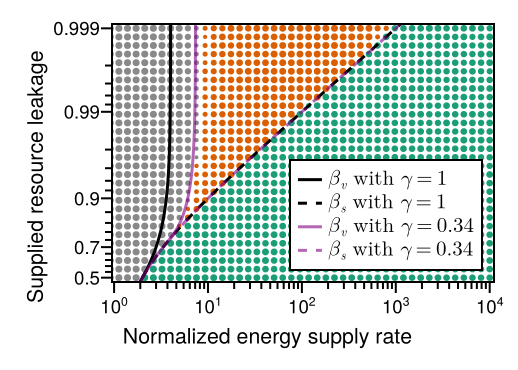

In [11]:
plotline_gpcols = [
    (1., 1., :black),
    (0.34, 1., (:purple, 0.6)),
    # (0.25, 1., (:pink, 0.6)),
]

fig = Figure(;
    size=(double_col_width * 0.38, (double_col_width / golden_ratio) * 0.44),
    figure_padding=(12., 12., 12., 12.),
)
ax = Axis(fig[1,1];
    # aspect=AxisAspect(1.2),
    xscale=log10,
    xlabelsize=8fontsize_pt,
    ylabelsize=8fontsize_pt,
    xlabelpadding=3.,
    ylabelpadding=3.,
    xlabel="Normalized energy supply rate            ",
    ylabel="Supplied resource leakage        ",
    xticklabelsize=7fontsize_pt,
    yticklabelsize=7fontsize_pt,
    xticklabelpad=0.,
    yticklabelpad=0.,
    xticks=log10ticks(-1:4),
    xminorticksvisible=true,
    xminorticks=IntervalsBetween(10),
    yminorticksvisible=true,
    xgridvisible=false,
    ygridvisible=false,
)
eps_ticks = [0.5, 0.3, 0.1, 0.01, 0.001]
ax.yticks = (LeakageScale.etox.(eps_ticks), [(@sprintf "%.3g" (1-e)) for e in eps_ticks])
ax.yminorticks = LeakageScale.exminorticks(eps_ticks, 4)
# ax.ylabel = L"l,\enspace\text{Supplied resource leakage}"
# ax.ylabel = L"l,\enspace\text{Supplied resource byproduct ratio}"
# ax.xlabel = L"K,\enspace\text{Amount of energy being supplied}"
# ax.xlabel = L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}"

# ternary colormap alternative
# cm = TernaryColormap(PaperColors.extinct(), PaperColors.stable(), PaperColors.unstable())
# xx = collect(zip(f1cmats[1], f1cmats[2], f1cmats[3]));
# yy = map(xx) do t t ./ sum(t) end;
# pd_colors = cm.(yy)'[:]

cols = [PaperColors.extinct(), PaperColors.stable(), PaperColors.unstable()]
xx = collect(zip(f1cmats[1], f1cmats[2], f1cmats[3]));
yy = map(xx) do t
    u = t ./ sum(t)
    mprop, mi = findmax(u)
    cols[mi], mprop
end;
pd_colors = getindex.(yy, 1)'[:]
minsize = 2
maxsize = 5
pd_sizes = minsize .+ ((getindex.(yy, 2) .- (1/3)) ./ (2/3)) .* (maxsize - minsize)

scatter!(ax, [(x, y) for x in f1Ks for y in f1leakxs];
    # marker='.',
    # markersize=4,
    markersize=pd_sizes'[:],
    color=pd_colors,
)

# pad the limits by half a grid step so the edge markers aren't cut in half
lKs = log10.(f1Ks)
xlim_lo = 10 ^ (lKs[1] - (lKs[2] - lKs[1]) / 2)
xlim_hi = 10 ^ (lKs[end] + (lKs[end] - lKs[end-1]) / 2)
ylim_lo = f1leakxs[1] - (f1leakxs[2] - f1leakxs[1]) / 2
ylim_hi = f1leakxs[end] + (f1leakxs[end] - f1leakxs[end-1]) / 2

for (gamma, p, color) in plotline_gpcols
    thr_leakxs = range(ylim_lo, ylim_hi, 1000)
    thr_ls = LeakageScale.l.(thr_leakxs)

    extline_Ks = MinimalModelV3.fr3_beta_viable.(thr_ls, gamma)
    instabline_Ks = MinimalModelV3.fr3_beta_s_qualified.(thr_ls, gamma, p)

    lines!(ax, extline_Ks, thr_leakxs;
        color,
        label=latexstring(@sprintf "\\beta_v \\text{ with } \\gamma=%.3g" gamma),
    )
    lines!(ax, instabline_Ks, thr_leakxs;
        color,
        linestyle=:dash,
        label=latexstring(@sprintf "\\beta_s \\text{ with } \\gamma=%.3g" gamma),
    )

    # xlims!(ax, xlim_lo, xlim_hi)
    xlims!(ax, 0.95, xlim_hi)
    ylims!(ax, ylim_lo, ylim_hi)
end
axislegend(ax;
    position=:rb,
    labelsize=7fontsize_ltex_pt,
    # framevisible=false,
    # backgroundcolor=:transparent,
    patchsize=(12., 4.),
    patchlabelgap=3.,
    rowgap=0.,
    colgap=4.,
    padding=(4., 4., 4., 4.),
    # tellwidth=false,
    # orientation=:horizontal,
    # nbanks=2,
    # halign=1.,
)

Makie.save("../../figures2/sifig_pd_gamma/outcomes_pd.pdf", fig)

fig